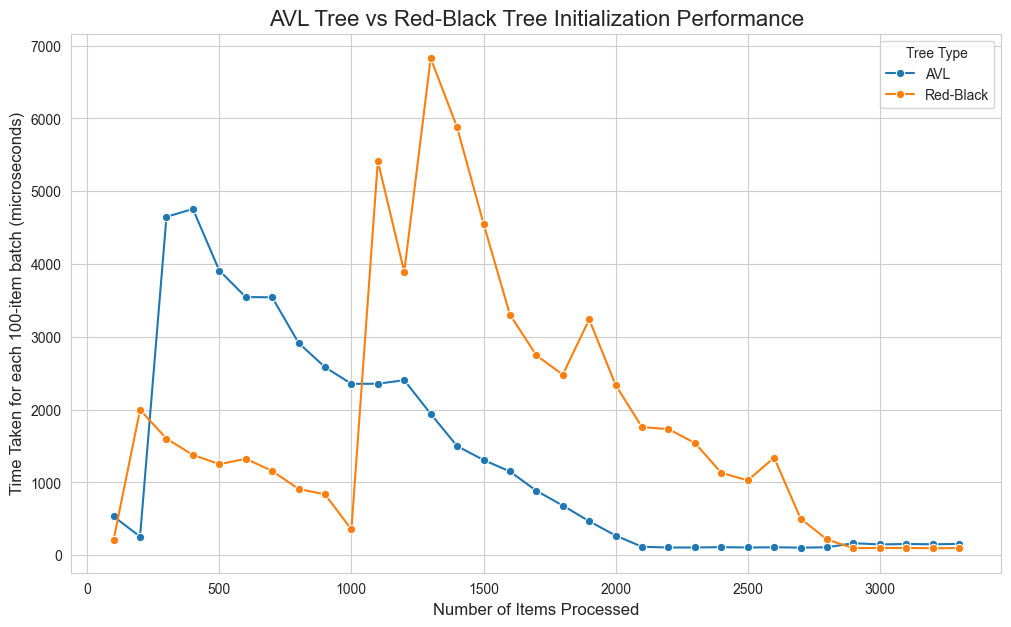

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_style("whitegrid")

# 读取CSV文件
df = pd.read_csv('performance_analysis.csv')

# 1. 按照operation筛选出init类型
init_df = df[df['Operation'] == 'init']

# 创建图表
plt.figure(figsize=(12, 7))

# 2. 按照TreeType分组，以ItemsProcessed为横轴，以Time_microseconds为纵轴绘制折线图
sns.lineplot(data=init_df, x='ItemsProcessed', y='Time_microseconds', hue='TreeType', marker='o')

# 设置图表标题和坐标轴标签
plt.title('AVL Tree vs Red-Black Tree Initialization Performance', fontsize=16)
plt.xlabel('Number of Items Processed', fontsize=12)
plt.ylabel('Time Taken for each 100-item batch (microseconds)', fontsize=12)
plt.legend(title='Tree Type')

# 显示网格
plt.grid(True)

# 显示图表
plt.show()

In [6]:
import random

input_filename = 'init.txt'
output_filename = 'init_random.txt'

try:
    with open(input_filename, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    # 保存第一行 "INSERT"
    header = lines[0]
    # 获取所有单词行
    word_lines = lines[1:]

    # 随机打乱单词行的顺序
    random.shuffle(word_lines)

    # 将打乱后的内容写入新文件
    with open(output_filename, 'w', encoding='utf-8') as f:
        # 先写入第一行 "INSERT"
        f.write(header)
        # 再写入随机排序后的单词行
        f.writelines(word_lines)

    print(f"成功！已将 '{input_filename}' 的内容随机化，并保存到 '{output_filename}'。")
    print(f"共处理并打乱了 {len(word_lines)} 个单词。")

except FileNotFoundError:
    print(f"错误：文件 '{input_filename}' 未找到。请确保它在正确的路径下。")
except Exception as e:
    print(f"处理文件时发生错误: {e}")

成功！已将 'init.txt' 的内容随机化，并保存到 'init_random.txt'。
共处理并打乱了 3328 个单词。


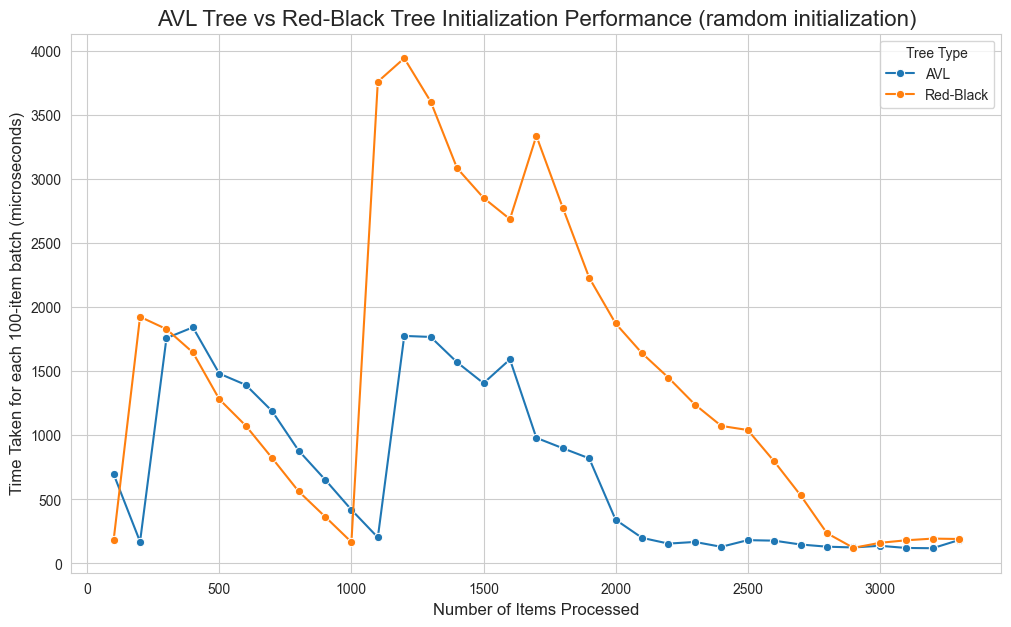

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_style("whitegrid")

# 读取CSV文件
df = pd.read_csv('performance_analysis_random.csv')

# 1. 按照operation筛选出init类型
init_df = df[df['Operation'] == 'init']

# 创建图表
plt.figure(figsize=(12, 7))

# 2. 按照TreeType分组，以ItemsProcessed为横轴，以Time_microseconds为纵轴绘制折线图
sns.lineplot(data=init_df, x='ItemsProcessed', y='Time_microseconds', hue='TreeType', marker='o')

# 设置图表标题和坐标轴标签
plt.title('AVL Tree vs Red-Black Tree Initialization Performance (ramdom initialization)', fontsize=16)
plt.xlabel('Number of Items Processed', fontsize=12)
plt.ylabel('Time Taken for each 100-item batch (microseconds)', fontsize=12)
plt.legend(title='Tree Type')

# 显示网格
plt.grid(True)

# 显示图表
plt.show()

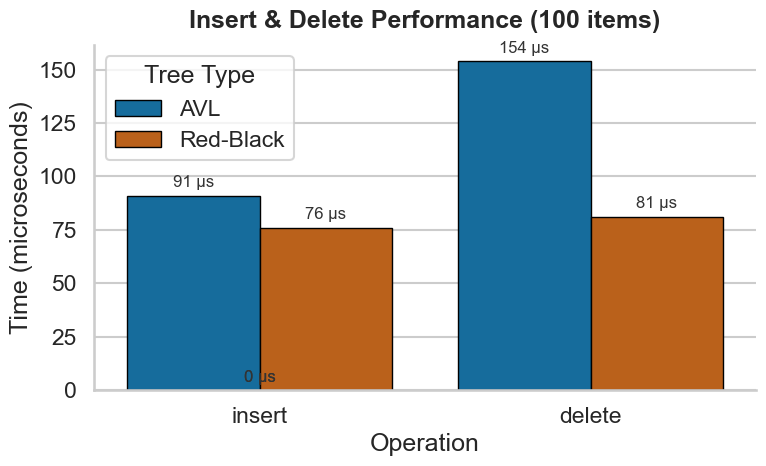

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 统一主题（talk 提升字号，白底网格）
sns.set_theme(style='whitegrid', context='talk')

# 读取数据
df = pd.read_csv('performance_analysis.csv')

# 只取 insert / delete 且处理数量为 100 的记录
plot_data = df[(df['Operation'].isin(['insert', 'delete']))]

# 操作显示顺序
operation_order = ['insert', 'delete']

# 自定义更柔和且高对比的配色（ColorBlind 友好）
palette = {
    'AVL': '#0072B2',        # 蓝
    'Red-Black': '#D55E00'   # 橙
}

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=plot_data,
    x='Operation',
    y='Time_microseconds',
    hue='TreeType',
    order=operation_order,
    palette=palette,
    edgecolor='black',
    linewidth=1
)

# 添加数值标注
for p in ax.patches:
    h = p.get_height()
    ax.annotate(
        f'{int(h)} μs',
        (p.get_x() + p.get_width() / 2, h),
        ha='center',
        va='bottom',
        fontsize=12,
        color='#333333',
        xytext=(0, 4),
        textcoords='offset points'
    )

# 标题与轴标签
ax.set_title('Insert & Delete Performance (100 items)', pad=12, weight='bold')
ax.set_xlabel('Operation')
ax.set_ylabel('Time (microseconds)')

# 图例优化
ax.legend(title='Tree Type')

# 去除顶部与右侧脊柱
sns.despine()

plt.tight_layout()
plt.show()

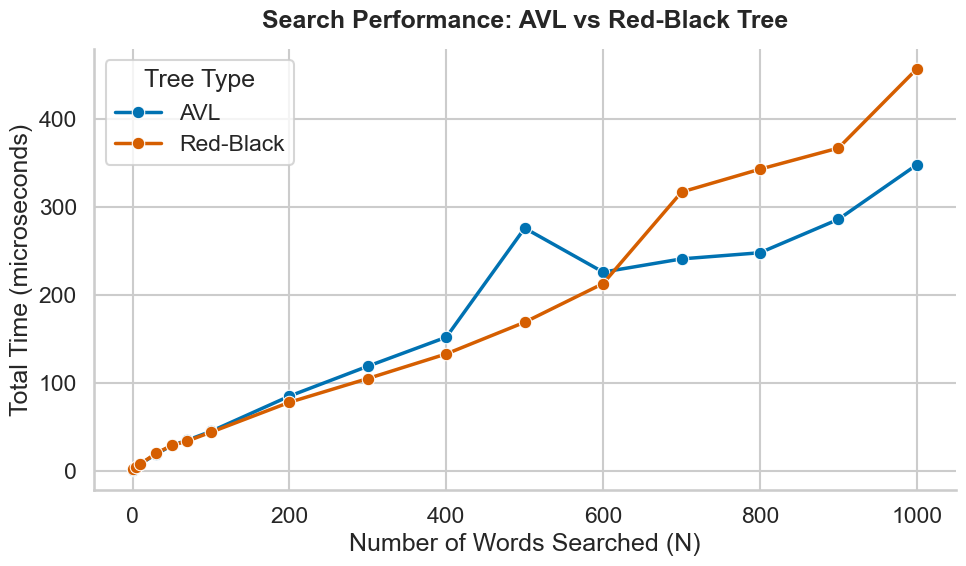

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 统一主题
sns.set_theme(style='whitegrid', context='talk')

# 读取数据
df = pd.read_csv('performance_analysis.csv')

# 筛选出 search 操作的数据
search_df = df[df['Operation'] == 'search']

# 自定义配色
palette = {
    'AVL': '#0072B2',        # 蓝
    'Red-Black': '#D55E00'   # 橙
}

# 创建图表
plt.figure(figsize=(10, 6))

# 绘制折线图
sns.lineplot(
    data=search_df, 
    x='ItemsProcessed', 
    y='Time_microseconds', 
    hue='TreeType', 
    marker='o',
    palette=palette,
    linewidth=2.5
)

# 设置标题和标签
plt.title('Search Performance: AVL vs Red-Black Tree', pad=15, weight='bold')
plt.xlabel('Number of Words Searched (N)')
plt.ylabel('Total Time (microseconds)')
plt.legend(title='Tree Type')

# 去除顶部与右侧脊柱
sns.despine()

plt.tight_layout()
plt.show()